In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('/media/carsen/ssd1/github/oneshot')
from utils import data
mouse_ids = [7,8,10,11,12]
save_path = './result'

In [4]:
rfsize_all = []
fecv_all = []
layers_all = []
areas_all = []
feve_all = []
fev_all = []
mf_all = []
msigma_all = []
mtheta_all = []
planes_all = []
all_depth_feve = []
area_names = ['V1', 'medial']
layer_names = ['layer 1', 'layer 2/3']
for i, mouse_id in enumerate(mouse_ids):
    res_dict = np.load(os.path.join(save_path, f'{data.mouse_names[mouse_id]}_{data.exp_date[mouse_id]}_fullmodel_result.npz'), allow_pickle=True)
    fev = res_dict['FEV'].astype(float)
    rf_size = res_dict['rf_size_visual'].astype(float)
    feve = res_dict['FEVE_fullmodel'].astype(float)
    fecv = res_dict['FECV'].astype(float)
    ilayer = res_dict['ilayer'].astype(int)
    iarea = res_dict['iarea'].astype(int)
    gabor_mf = res_dict['gabor_mf'].astype(float)
    gabor_msigma = res_dict['gabor_msigma'].astype(float)
    gabor_mtheta = res_dict['gabor_mtheta'].astype(float)
    depth_feve = res_dict['FEVE_all_depth'].astype(float) # (n_depth, n_neurons)
    all_depth_feve.append(depth_feve)
    rfsize_all.append(rf_size)
    fecv_all.append(fecv)
    feve_all.append(feve)
    fev_all.append(fev)
    layers_all.append(ilayer)
    areas_all.append(iarea)
    mf_all.append(gabor_mf)
    msigma_all.append(gabor_msigma)
    mtheta_all.append(gabor_mtheta)
rfsize_all = np.concatenate(rfsize_all)
fecv_all = np.concatenate(fecv_all)
feve_all = np.concatenate(feve_all)
fev_all = np.concatenate(fev_all)
layers_all = np.concatenate(layers_all)
areas_all = np.concatenate(areas_all)
mf_all = np.concatenate(mf_all)
msigma_all = np.concatenate(msigma_all)
mtheta_all = np.concatenate(mtheta_all)
all_depth_feve = np.concatenate(all_depth_feve, axis=1) # (n_depth, n_neurons_total)

print(f'rfsize_all: {rfsize_all.shape}, fecv_all: {fecv_all.shape}, feve_all: {feve_all.shape}, fev_all: {fev_all.shape}, layers_all: {layers_all.shape}, areas_all: {areas_all.shape}, mf_all: {mf_all.shape}, msigma_all: {msigma_all.shape}, mtheta_all: {mtheta_all.shape}')

rfsize_all: (6596,), fecv_all: (6596,), feve_all: (6596,), fev_all: (6596,), layers_all: (6596,), areas_all: (6596,), mf_all: (6596,), msigma_all: (6596,), mtheta_all: (6596,)


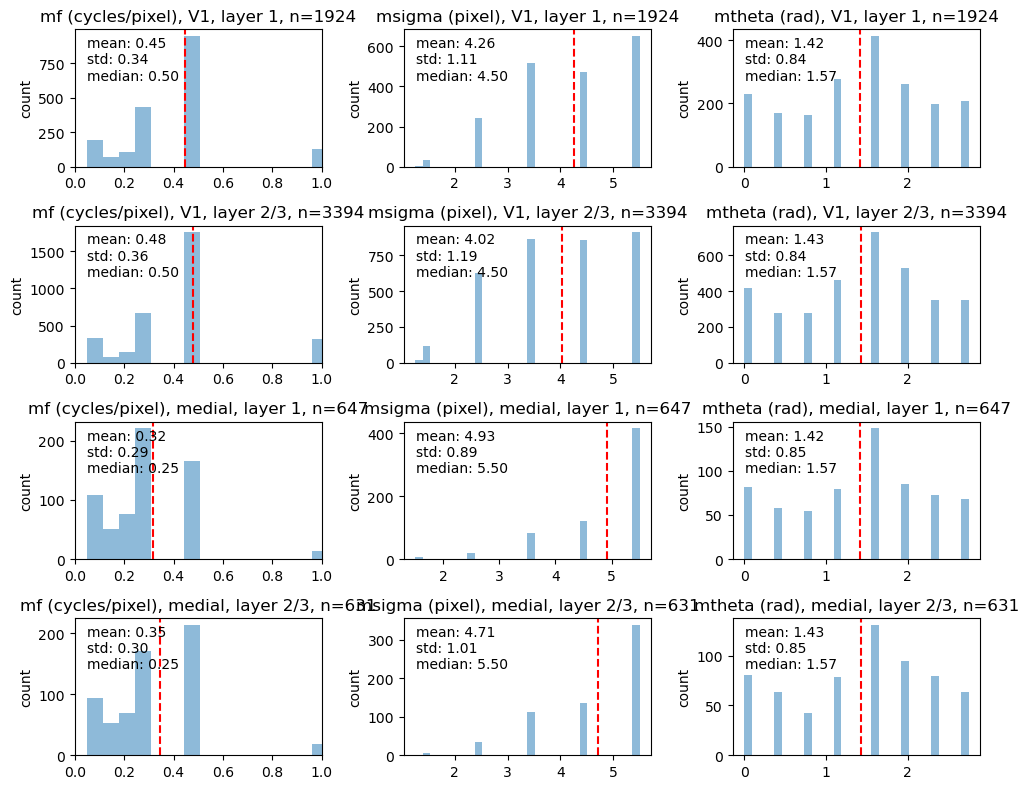

In [5]:
fig, ax = plt.subplots(4, 3, figsize=(10,8))
gabor_mf = mf_all
gabor_msigma = msigma_all
gabor_mtheta = mtheta_all
vars = [gabor_mf, gabor_msigma, gabor_mtheta]
ilayers = layers_all
iareas = areas_all
var_names = ['mf (cycles/pixel)', 'msigma (pixel)', 'mtheta (rad)']
for i in range(3):
    var_plot = vars[i]
    var_name = var_names[i]
    for iarea in range(2):
        area_name = 'V1' if iarea==0 else 'medial'
        for ilayer in range(2):
            indexes = np.where((iareas == iarea) & (ilayers == (ilayer+1)))[0]
            layer_name = 'layer 1' if ilayer==0 else 'layer 2/3'
            ax[ilayer+iarea*2, i].hist(var_plot[indexes], bins=30, alpha=0.5)
            ax[ilayer+iarea*2, i].set_title(f'{var_name}, {area_name}, {layer_name}, n={len(indexes)}')
            mu = np.mean(var_plot[indexes])
            sd = np.std(var_plot[indexes])
            med = np.median(var_plot[indexes])
            ax[ilayer+iarea*2, i].axvline(mu, color='red', linestyle='--', label='mean')
            # add std band
            # ax[ilayer+iarea*2, i].axvspan(mu-sd, mu+sd, color='orange', alpha=0.3, label='std')
            # ax[i, ilayer+iarea*2].axvline(mu+sd, color='orange', linestyle='--', label='std')
            ax[ilayer+iarea*2, i].text(0.05, 0.95, f'mean: {mu:.2f}\nstd: {sd:.2f}\nmedian: {med:.2f}', transform=ax[ilayer+iarea*2, i].transAxes, fontsize=10, verticalalignment='top')
            if i==0: ax[ilayer+iarea*2, i].set_xlim([0, 1])
            # if i==1: ax[ilayer+iarea*2, i].set_xlim([0, 1])
            # if i==2: ax[ilayer+iarea*2, i].set_xlim([0, 40])
            ax[ilayer+iarea*2, i].set_ylabel('count')
plt.tight_layout()

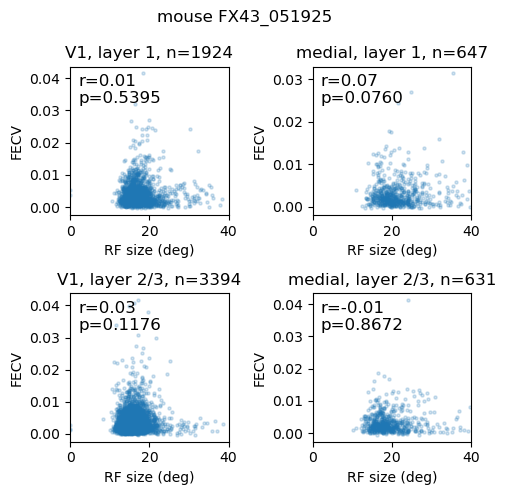

In [6]:
# rfsize vs fecv for different layers and areas
fig, ax = plt.subplots(2, 2, figsize=(5,5))
fecv = fecv_all
rfsize = rfsize_all
iareas = areas_all
ilayers = layers_all
for iarea in range(2):
    for ilayer in range(2):
        ax_ = ax[ilayer, iarea]
        idxes = np.where((iareas==iarea) & (ilayers==(ilayer+1)))[0]
        ax_.scatter(rfsize[idxes], fecv[idxes], s=5, alpha=0.2)
        ax_.set_title(f'{area_names[iarea]}, {layer_names[ilayer]}, n={len(idxes)}')
        # statistics
        from scipy import stats
        r, p = stats.pearsonr(rfsize[idxes], fecv[idxes])
        ax_.text(0.05, 0.95, f'r={r:.2f}\np={p:.4f}', transform=ax_.transAxes, fontsize=12, verticalalignment='top')
        ax_.set_xlabel('RF size (deg)')
        ax_.set_ylabel('FECV')
        ax_.set_xlim([0, 40])
plt.suptitle(f'mouse {data.mouse_names[mouse_id]}_{data.exp_date[mouse_id]}')
plt.tight_layout()

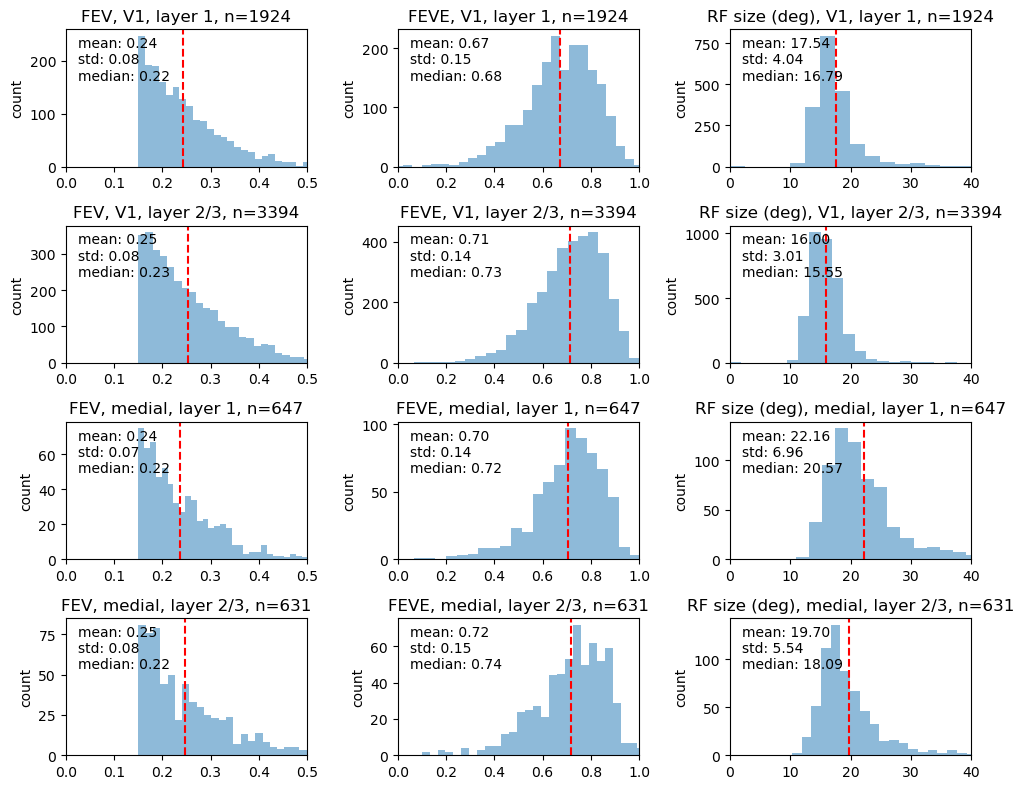

In [7]:
fig, ax = plt.subplots(4, 3, figsize=(10,8))
vars = [fev_all, feve_all, rfsize_all]
var_names = ['FEV', 'FEVE', 'RF size (deg)']
for i in range(3):
    var_plot = vars[i]
    var_name = var_names[i]
    for iarea in range(2):
        area_name = 'V1' if iarea==0 else 'medial'
        for ilayer in range(2):
            # indexes = idxes[res_dict['ilayer'][idxes]==(ilayer+1)]
            indexes = np.where((areas_all==iarea) & (layers_all==(ilayer+1)))[0]
            layer_name = 'layer 1' if ilayer==0 else 'layer 2/3'
            ax[ilayer+iarea*2, i].hist(var_plot[indexes], bins=30, alpha=0.5)
            ax[ilayer+iarea*2, i].set_title(f'{var_name}, {area_name}, {layer_name}, n={len(indexes)}')
            mu = np.mean(var_plot[indexes])
            sd = np.std(var_plot[indexes])
            med = np.median(var_plot[indexes])
            ax[ilayer+iarea*2, i].axvline(mu, color='red', linestyle='--', label='mean')
            # ax[i, ilayer+iarea*2].axvline(mu+sd, color='orange', linestyle='--', label='std')
            ax[ilayer+iarea*2, i].text(0.05, 0.95, f'mean: {mu:.2f}\nstd: {sd:.2f}\nmedian: {med:.2f}', transform=ax[ilayer+iarea*2, i].transAxes, fontsize=10, verticalalignment='top')
            if i==0: ax[ilayer+iarea*2, i].set_xlim([0, 0.5])
            if i==1: ax[ilayer+iarea*2, i].set_xlim([0, 1])
            if i==2: ax[ilayer+iarea*2, i].set_xlim([0, 40])
            ax[ilayer+iarea*2, i].set_ylabel('count')
plt.tight_layout()

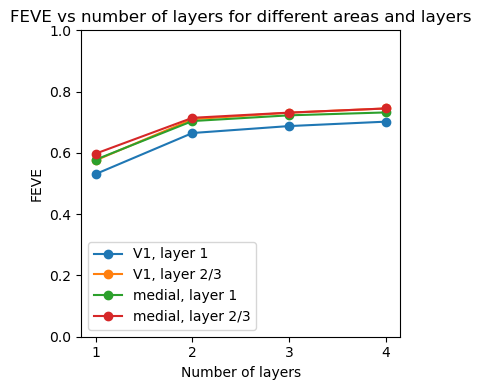

In [8]:
# plot all depth feve with different areas and layers
fig, ax = plt.subplots(1, 1, figsize=(4,4))
n_depth = all_depth_feve.shape[0]
depths = np.arange(1, n_depth+1)
for iarea in range(2):
    area_name = 'V1' if iarea==0 else 'medial'
    for ilayer in range(2):
        indexes = np.where((areas_all==iarea) & (layers_all==(ilayer+1)))[0]
        layer_name = 'layer 1' if ilayer==0 else 'layer 2/3'
        feve_mean = np.mean(all_depth_feve[:, indexes], axis=1)
        ax.plot(depths, feve_mean, marker='o', label=f'{area_name}, {layer_name}')
ax.set_xlabel('Number of layers')
ax.set_ylabel('FEVE')
ax.set_title('FEVE vs number of layers for different areas and layers')
ax.set_xticks(depths)
ax.set_ylim([0, 1])
ax.legend()
plt.tight_layout()